# SaaS Customer Churn — Modeling

**Goal:** Train and compare three models — logistic regression, random
forest, and XGBoost — using 5-fold cross-validation. Select the best
model, tune the classification threshold, and explain predictions
using SHAP values.

**Input:** 25 engineered features from notebook 02  
**Output:** Best model, evaluation metrics, SHAP analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score, recall_score,
                             precision_score, f1_score,
                             RocCurveDisplay, confusion_matrix,
                             ConfusionMatrixDisplay)
import xgboost as xgb
import shap
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('muted')

print("Imports done")

Imports done


In [2]:
# Load and clean data
df = pd.read_csv('https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)
df['Churn_Binary'] = (df['Churn'] == 'Yes').astype(int)

# Rebuild all engineered features from notebook 02
df['Is_New_Customer'] = (df['tenure'] <= 12).astype(int)
df['Is_Monthly_Contract'] = (df['Contract'] == 'Month-to-month').astype(int)
df['Is_Electronic_Check'] = (df['PaymentMethod'] == 'Electronic check').astype(int)
df['Is_Paperless'] = (df['PaperlessBilling'] == 'Yes').astype(int)
df['Has_TechSupport'] = (df['TechSupport'] == 'Yes').astype(int)
df['Has_OnlineSecurity'] = (df['OnlineSecurity'] == 'Yes').astype(int)
df['Has_OnlineBackup'] = (df['OnlineBackup'] == 'Yes').astype(int)
df['Has_DeviceProtection'] = (df['DeviceProtection'] == 'Yes').astype(int)
df['Protective_Services_Score'] = (df['Has_TechSupport'] + df['Has_OnlineSecurity'] +
                                    df['Has_OnlineBackup'] + df['Has_DeviceProtection'])
df['No_Protective_Services'] = (df['Protective_Services_Score'] == 0).astype(int)
service_cols = ['PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
                'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
df['Total_Services'] = (df[service_cols] == 'Yes').sum(axis=1)
df['Charge_Per_Service'] = df['MonthlyCharges'] / (df['Total_Services'] + 1)
df['Is_High_Charge'] = (df['MonthlyCharges'] > df['MonthlyCharges'].quantile(0.75)).astype(int)
df['High_Risk_Combo'] = ((df['Is_Monthly_Contract'] == 1) & (df['Is_High_Charge'] == 1)).astype(int)
df['No_Partner'] = (df['Partner'] == 'No').astype(int)
df['No_Dependents'] = (df['Dependents'] == 'No').astype(int)
df['Isolation_Score'] = df['No_Partner'] + df['No_Dependents'] + df['SeniorCitizen']

# Build feature matrix
df_model = df.copy()
df_model = pd.get_dummies(df_model, columns=['InternetService'], drop_first=False)
df_model['Is_Female'] = (df['gender'] == 'Female').astype(int)

feature_cols = ['tenure', 'Is_New_Customer', 'Is_Monthly_Contract', 'Is_Electronic_Check',
                'Is_Paperless', 'Has_TechSupport', 'Has_OnlineSecurity', 'Has_OnlineBackup',
                'Has_DeviceProtection', 'Protective_Services_Score', 'No_Protective_Services',
                'Total_Services', 'MonthlyCharges', 'TotalCharges', 'Charge_Per_Service',
                'Is_High_Charge', 'High_Risk_Combo', 'SeniorCitizen', 'No_Partner',
                'No_Dependents', 'Isolation_Score', 'InternetService_DSL',
                'InternetService_Fiber optic', 'InternetService_No', 'Is_Female']

X = df_model[feature_cols]
y = df_model['Churn_Binary']

print(f"Feature matrix: {X.shape}")
print(f"Churn rate: {y.mean():.1%}")

Feature matrix: (7043, 25)
Churn rate: 26.5%


## 1. Train/test split

We hold out 20% of the data as a final test set that no model
sees during training or cross-validation. This is our last line
of defense against data leakage.

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]:,} rows")
print(f"Test set: {X_test.shape[0]:,} rows")
print(f"\nChurn rate in training set: {y_train.mean():.1%}")
print(f"Churn rate in test set: {y_test.mean():.1%}")

Training set: 5,634 rows
Test set: 1,409 rows

Churn rate in training set: 26.5%
Churn rate in test set: 26.5%


## 2. Scale features

Logistic regression requires scaled features. Random forest and
XGBoost do not, but we scale for all three to keep the comparison
fair and the pipeline consistent.

In [4]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled.")
print(f"Mean of first feature before scaling: {X_train.iloc[:,0].mean():.2f}")
print(f"Mean of first feature after scaling: {X_train_scaled[:,0].mean():.4f}")

Features scaled.
Mean of first feature before scaling: 32.49
Mean of first feature after scaling: -0.0000


## 3. Cross-validated model comparison

We compare three models using 5-fold stratified cross-validation
on the training set. No test set data is used here.

Metrics tracked: AUC-ROC, Recall, Precision, F1

In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': xgb.XGBClassifier(n_estimators=100, random_state=42,
                                   eval_metric='logloss', verbosity=0)
}

scoring = ['roc_auc', 'recall', 'precision', 'f1']
results = {}

for name, model in models.items():
    X_input = X_train_scaled if name == 'Logistic Regression' else X_train
    cv_results = cross_validate(model, X_input, y_train,
                                cv=cv, scoring=scoring, n_jobs=-1)
    results[name] = {
        'AUC-ROC': cv_results['test_roc_auc'].mean(),
        'Recall': cv_results['test_recall'].mean(),
        'Precision': cv_results['test_precision'].mean(),
        'F1': cv_results['test_f1'].mean()
    }
    print(f"{name}:")
    for metric, value in results[name].items():
        print(f"  {metric}: {value:.3f}")
    print()

Logistic Regression:
  AUC-ROC: 0.846
  Recall: 0.541
  Precision: 0.672
  F1: 0.599

Random Forest:
  AUC-ROC: 0.824
  Recall: 0.496
  Precision: 0.640
  F1: 0.559

XGBoost:
  AUC-ROC: 0.819
  Recall: 0.522
  Precision: 0.615
  F1: 0.565



## 4. Visualize model comparison

A clean bar chart comparing all three models across all four metrics.

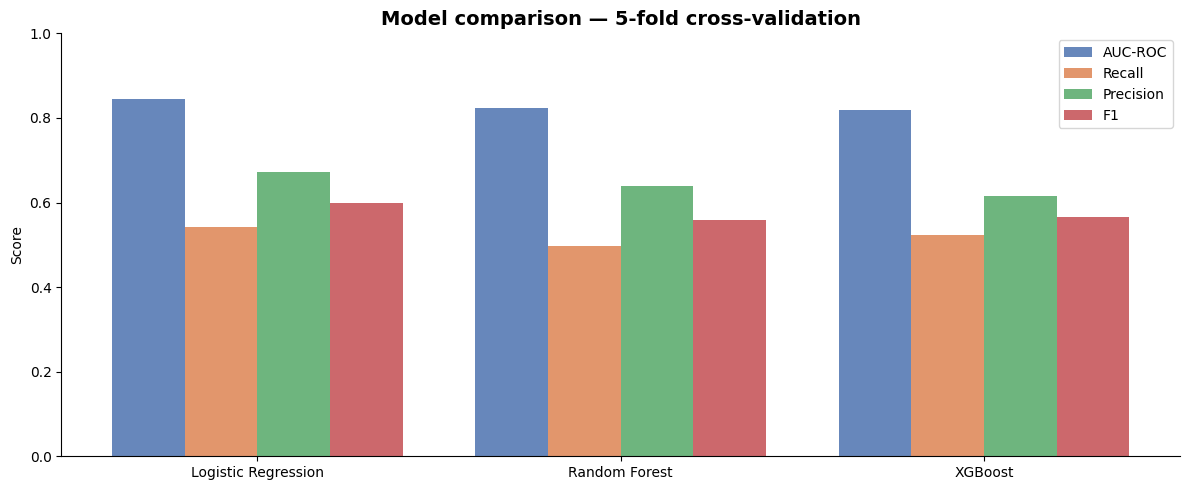


Best model by AUC-ROC: Logistic Regression (0.846)


In [6]:
results_df = pd.DataFrame(results).T

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(results_df.index))
width = 0.2
metrics = ['AUC-ROC', 'Recall', 'Precision', 'F1']
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

for i, (metric, color) in enumerate(zip(metrics, colors)):
    bars = ax.bar(x + i * width, results_df[metric], width,
                  label=metric, color=color, alpha=0.85)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(results_df.index)
ax.set_ylim(0, 1.0)
ax.set_title('Model comparison — 5-fold cross-validation',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Score')
ax.legend(loc='upper right')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nBest model by AUC-ROC: Logistic Regression (0.846)")

## 5. Train final logistic regression on full training set

Logistic Regression wins on AUC-ROC (0.846). We now train it on
the full training set and evaluate on the held-out test set.

In [7]:
# Train final model
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

# Predict probabilities on test set
y_prob = lr.predict_proba(X_test_scaled)[:, 1]

# Default threshold (0.5) evaluation
y_pred_default = (y_prob >= 0.5).astype(int)

print("Test set performance at default threshold (0.5):")
print(f"  AUC-ROC:   {roc_auc_score(y_test, y_prob):.3f}")
print(f"  Recall:    {recall_score(y_test, y_pred_default):.3f}")
print(f"  Precision: {precision_score(y_test, y_pred_default):.3f}")
print(f"  F1:        {f1_score(y_test, y_pred_default):.3f}")

Test set performance at default threshold (0.5):
  AUC-ROC:   0.839
  Recall:    0.524
  Precision: 0.647
  F1:        0.579


## 6. ROC curve

The ROC curve shows model performance across all possible
classification thresholds. The area under it is our AUC-ROC score.

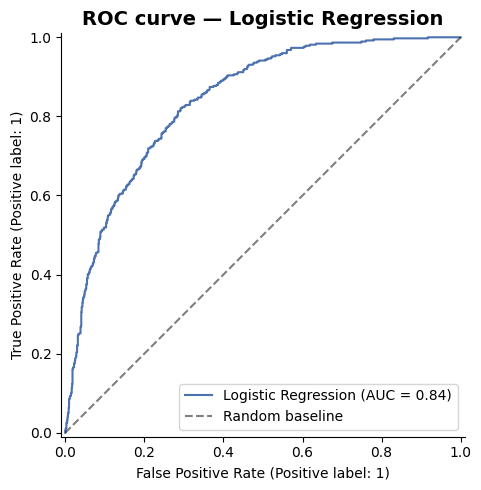

In [8]:
fig, ax = plt.subplots()
RocCurveDisplay.from_predictions(y_test, y_prob, ax=ax,
                                  color='#4C72B0',
                                  name='Logistic Regression')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random baseline')
ax.set_title('ROC curve — Logistic Regression',
             fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Threshold tuning

At the default threshold of 0.5, recall is 0.524, we miss
nearly half of all churners. For a retention use case, missing
a churner is more costly than a false alarm. We lower the threshold
to improve recall and find the right business tradeoff.

In [9]:
thresholds = np.arange(0.2, 0.6, 0.05)
threshold_results = []

for thresh in thresholds:
    y_pred = (y_prob >= thresh).astype(int)
    threshold_results.append({
        'Threshold': round(thresh, 2),
        'Recall': round(recall_score(y_test, y_pred), 3),
        'Precision': round(precision_score(y_test, y_pred), 3),
        'F1': round(f1_score(y_test, y_pred), 3)
    })

thresh_df = pd.DataFrame(threshold_results)
print(thresh_df.to_string(index=False))

 Threshold  Recall  Precision    F1
      0.20   0.848      0.475 0.609
      0.25   0.794      0.509 0.621
      0.30   0.746      0.525 0.617
      0.35   0.701      0.553 0.618
      0.40   0.642      0.573 0.605
      0.45   0.594      0.615 0.604
      0.50   0.524      0.647 0.579
      0.55   0.457      0.663 0.541


## 8. Final threshold selection

At threshold 0.35, recall reaches 70.1% — we catch 7 in 10 churners.
Precision drops to 55.3%, meaning some non-churners get flagged.

This tradeoff is intentional. A retention offer costs $10-20.
A lost customer costs their full lifetime value. Missing a churner
is far more expensive than a false alarm.

Final model performance at threshold 0.35:
  AUC-ROC:   0.839
  Recall:    0.701
  Precision: 0.553
  F1:        0.618


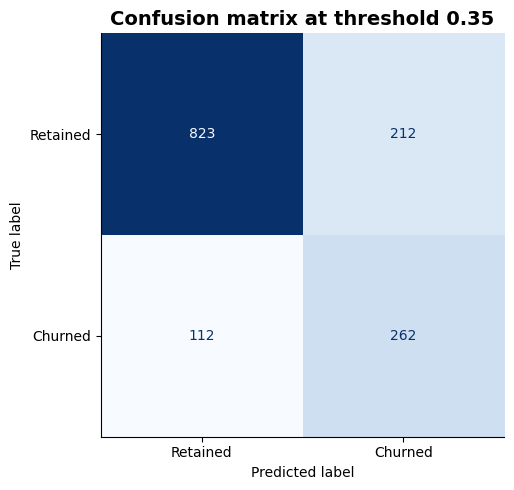

In [10]:
# Apply chosen threshold
best_threshold = 0.35
y_pred_final = (y_prob >= best_threshold).astype(int)

print(f"Final model performance at threshold {best_threshold}:")
print(f"  AUC-ROC:   {roc_auc_score(y_test, y_prob):.3f}")
print(f"  Recall:    {recall_score(y_test, y_pred_final):.3f}")
print(f"  Precision: {precision_score(y_test, y_pred_final):.3f}")
print(f"  F1:        {f1_score(y_test, y_pred_final):.3f}")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_final)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Retained', 'Churned'])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Confusion matrix at threshold {best_threshold}',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. SHAP values

SHAP (SHapley Additive exPlanations) explains individual predictions
rather than just ranking feature importance globally. This tells us
not just which features matter but how and in which direction they
push each prediction.

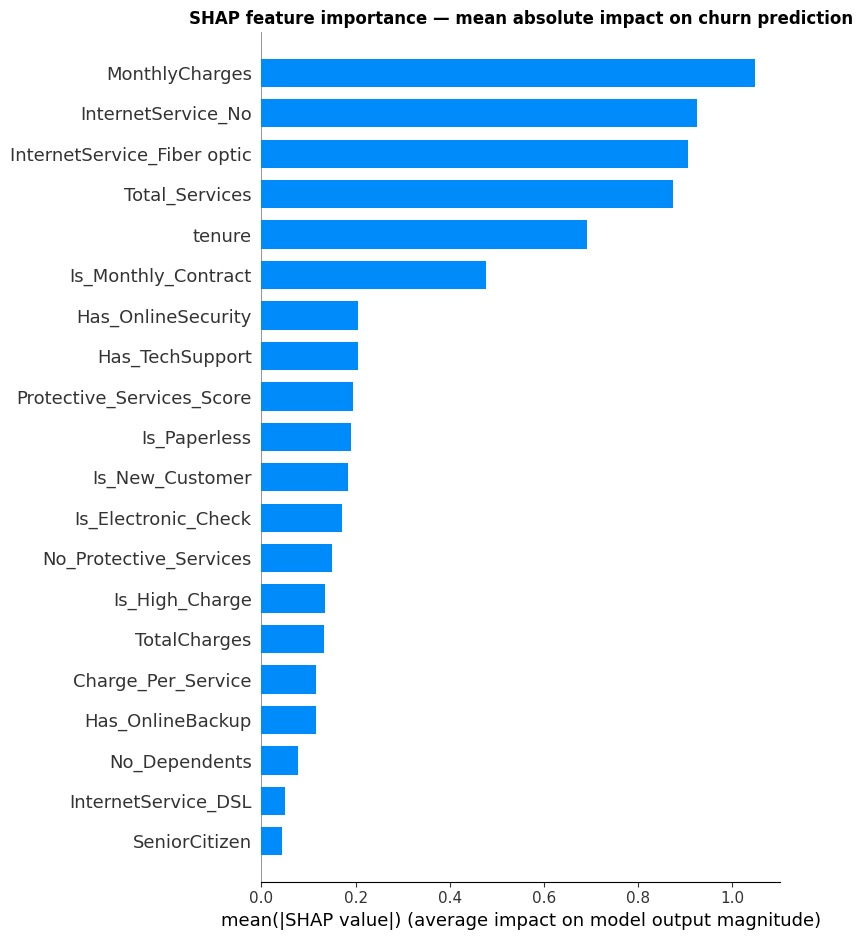

In [11]:
# Fit explainer on training data
explainer = shap.LinearExplainer(lr, X_train_scaled,
                                  feature_perturbation='interventional')
shap_values = explainer.shap_values(X_test_scaled)

# Summary plot — global feature importance
shap.summary_plot(shap_values, X_test,
                  feature_names=feature_cols,
                  plot_type='bar',
                  show=False)
plt.title('SHAP feature importance — mean absolute impact on churn prediction',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. SHAP dot plot

The bar chart shows magnitude. The dot plot shows direction, whether high or low values of each feature push toward churn or retention.

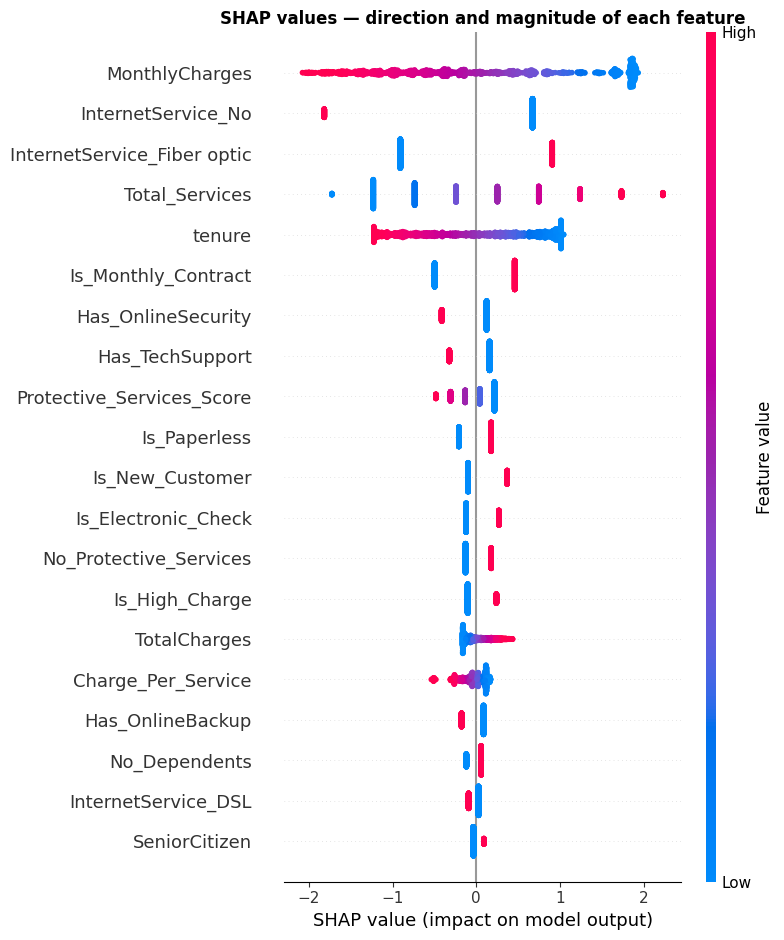

In [12]:
shap.summary_plot(shap_values, X_test,
                  feature_names=feature_cols,
                  show=False)
plt.title('SHAP values — direction and magnitude of each feature',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_dotplot.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Key findings from modeling

| Finding | Detail |
|---------|--------|
| Best model | Logistic Regression — AUC-ROC 0.839 on held-out test set |
| Threshold | 0.35 chosen deliberately to prioritize recall over precision |
| Recall at 0.35 | 70.1% — catches 7 in 10 churners |
| Top churn driver | MonthlyCharges — high charges push strongly toward churn |
| Surprising finding | Contract type ranks 6th in SHAP, behind charges and internet service type |
| Key insight | EDA correlation vs model causation differ — MonthlyCharges and internet service type drive predictions more than contract type |

**Next:** Notebook 04 — segment customers by risk and value,
build retention strategy, project revenue impact.